In [1]:
from src.features import add_moving_averages, add_returns
from src.backtest import run_ma_strategy
from src.metrics import summary
from src.data_loader import load_binance_data_csv
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = load_binance_data_csv()

# 2. Features
df = add_returns(df)
df = add_moving_averages(df, fast=50, slow=200)

df = run_ma_strategy(df, fee=0.001)

metrics = pd.DataFrame({
    "MA50/200":   summary(df["strategy_equity"], df["strategy_return"]),
    "Buy & Hold": summary(df["market_equity"],  df["market_return"]),
})
metrics

,MA50/200,Buy & Hold
ROI %,86.13,64.71
Sharpe,0.58,0.48
Sortino,0.66,0.68
Calmar,0.41,0.18
Max Drawdown %,-37.25,-66.73
Win Rate %,26.23,49.41


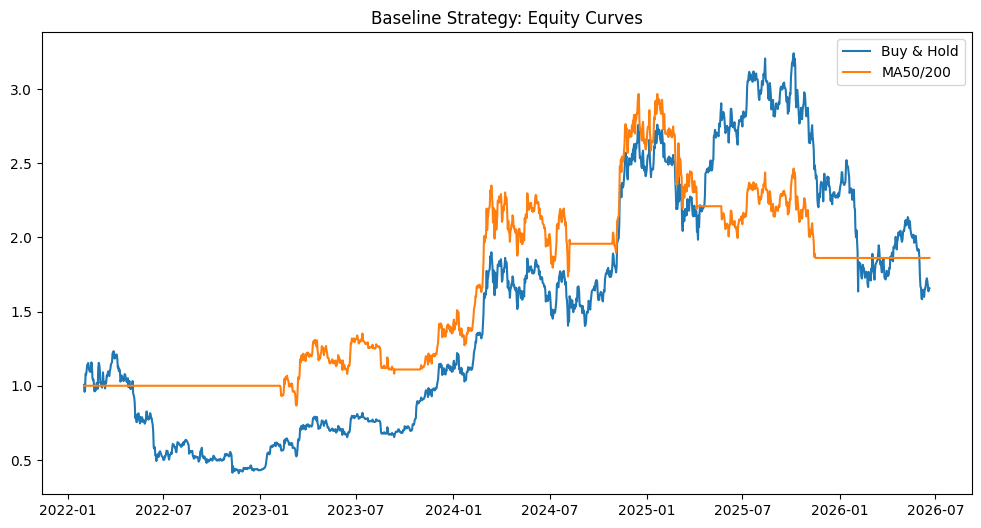

In [3]:
plt.figure(figsize=(12, 6))
plt.plot(df["timestamp"], df["market_equity"], label="Buy & Hold")
plt.plot(df["timestamp"], df["strategy_equity"], label="MA50/200")
plt.legend()
plt.title("Baseline Strategy: Equity Curves")
plt.show()